### Ньяти Каелиле БВТ2201
### Lab 8

### Exercise 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate


#Для воспроизводимости результатов
np.random.seed(42)



In [17]:
# Задание №1
# Разработка имитационной модели многоканальной системы с отказами

def generate_exponential(rate):
    """
    Генерация экспоненциально распределенной случайной величины
    rate - интенсивность (1/сек)
    """
    u = np.random.rand()
    return -(1/rate) * np.log(u)

def multichannel_queuing_system(lambda_rate, mu_rate, n_channels, T_simulation):
    """
    Имитационное моделирование многоканальной системы с отказами
    
    Параметры:
    lambda_rate - интенсивность входного потока [1/сек]
    mu_rate - интенсивность обработки [1/сек]
    n_channels - количество каналов
    T_simulation - время моделирования [сек]
    
    Возвращает:
    dict - выходные характеристики системы
    """
    
    # Инициализация массивов для хранения состояний каналов
    # TS - время освобождения канала
    TS = np.zeros(n_channels)
    # TP - суммарное время обработки заявок каждым каналом
    TP = np.zeros(n_channels)
    
    # Счетчики
    total_requests = 0  # общее число поступивших заявок
    processed_requests = 0  # число обработанных заявок
    rejected_requests = 0  # число отказов
    
    current_time = 0  # текущее время моделирования
    
    # Генерация времени поступления первой заявки
    current_time += generate_exponential(lambda_rate)
    
    while current_time < T_simulation:
        total_requests += 1
        
        # Поиск свободного канала
        free_channel = -1
        min_release_time = float('inf')
        earliest_channel = -1
        
        for i in range(n_channels):
            if TS[i] <= current_time:
                free_channel = i
                break
            if TS[i] < min_release_time:
                min_release_time = TS[i]
                earliest_channel = i
        
        if free_channel != -1:
            # Есть свободный канал - заявка принимается к обслуживанию
            processed_requests += 1
            
            # Генерация времени обработки
            service_time = generate_exponential(mu_rate)
            
            # Обновление времени освобождения канала
            TS[free_channel] = current_time + service_time
            
            # Обновление суммарного времени обработки для канала
            TP[free_channel] += service_time
        else:
            # Все каналы заняты - заявка получает отказ
            rejected_requests += 1
        
        # Генерация времени поступления следующей заявки
        current_time += generate_exponential(lambda_rate)
    
    # Расчет выходных характеристик
    probability_processed = processed_requests / total_requests if total_requests > 0 else 0
    probability_rejected = rejected_requests / total_requests if total_requests > 0 else 0
    
    # Время простоя каналов
    idle_time = np.zeros(n_channels)
    for i in range(n_channels):
        if TS[i] < T_simulation:
            idle_time[i] = T_simulation - TS[i]
        else:
            idle_time[i] = 0
    
    # Вероятность загрузки каналов
    channel_utilization = TP / T_simulation
    
    results = {
        'total_requests': total_requests,
        'processed_requests': processed_requests,
        'rejected_requests': rejected_requests,
        'probability_processed': probability_processed,
        'probability_rejected': probability_rejected,
        'channel_idle_time': idle_time,
        'channel_utilization': channel_utilization,
        'avg_channel_utilization': np.mean(channel_utilization)
    }
    
    return results

# Демонстрация работы модели
print("=" * 60)
print("Задание №1: Демонстрация работы имитационной модели")
print("=" * 60)

# Тестовый прогон модели
test_results = multichannel_queuing_system(
    lambda_rate=0.2, 
    mu_rate=0.1, 
    n_channels=2, 
    T_simulation=1000
)

print(f"\nРезультаты моделирования:")
print(f"Всего поступило заявок: {test_results['total_requests']}")
print(f"Обработано заявок: {test_results['processed_requests']}")
print(f"Отказов: {test_results['rejected_requests']}")
print(f"Вероятность обработки: {test_results['probability_processed']:.4f}")
print(f"Вероятность отказа: {test_results['probability_rejected']:.4f}")
print(f"Средняя загрузка каналов: {test_results['avg_channel_utilization']:.4f}")
print(f"\nЗагрузка по каналам:")
for i in range(2):
    print(f"  Канал {i+1}: {test_results['channel_utilization'][i]:.4f}")

Задание №1: Демонстрация работы имитационной модели

Результаты моделирования:
Всего поступило заявок: 200
Обработано заявок: 118
Отказов: 82
Вероятность обработки: 0.5900
Вероятность отказа: 0.4100
Средняя загрузка каналов: 0.6384

Загрузка по каналам:
  Канал 1: 0.7235
  Канал 2: 0.5533


### Exercise 2

In [18]:
# Задание №2
# Расчет для заданных входных параметров и сопоставление с аналитическими значениями

print("=" * 60)
print("Задание №2: Расчет для фиксированных параметров")
print("=" * 60)

# Параметры моделирования
lambda_rate = 0.2  # интенсивность входного потока [1/сек]
mu_rate = 0.1      # интенсивность обработки [1/сек]
n_channels = 2     # количество каналов
T_simulation = 1000  # время моделирования [сек]

# Количество прогонов для усреднения результатов
num_runs = 10

print(f"\nПараметры моделирования:")
print(f"λ = {lambda_rate} [1/сек]")
print(f"μ = {mu_rate} [1/сек]")
print(f"n = {n_channels}")
print(f"T = {T_simulation} [сек]")
print(f"Количество прогонов: {num_runs}")

# Модифицированная функция для возврата всех необходимых параметров
def multichannel_queuing_system_detailed(lambda_rate, mu_rate, n_channels, T_simulation):
    """
    Детальная версия функции с возвратом всех необходимых параметров
    """
    
    # Инициализация массивов для хранения состояний каналов
    TS = np.zeros(n_channels)  # время освобождения канала
    TP = np.zeros(n_channels)  # суммарное время обработки
    
    # Для расчета абсолютной пропускной способности
    processed_requests = 0
    
    # Счетчики
    total_requests = 0
    rejected_requests = 0
    
    current_time = 0
    
    # Генерация времени поступления первой заявки
    current_time += generate_exponential(lambda_rate)
    
    while current_time < T_simulation:
        total_requests += 1
        
        # Поиск свободного канала
        free_channel = -1
        for i in range(n_channels):
            if TS[i] <= current_time:
                free_channel = i
                break
        
        if free_channel != -1:
            # Есть свободный канал - заявка принимается к обслуживанию
            processed_requests += 1
            
            # Генерация времени обработки
            service_time = generate_exponential(mu_rate)
            
            # Обновление времени освобождения канала
            TS[free_channel] = current_time + service_time
            
            # Обновление суммарного времени обработки
            TP[free_channel] += service_time
        else:
            # Все каналы заняты - заявка получает отказ
            rejected_requests += 1
        
        # Генерация времени поступления следующей заявки
        current_time += generate_exponential(lambda_rate)
    
    # Расчет выходных характеристик
    probability_processed = processed_requests / total_requests if total_requests > 0 else 0
    probability_rejected = rejected_requests / total_requests if total_requests > 0 else 0
    
    # Абсолютная пропускная способность (среднее число заявок, обслуженных в единицу времени)
    A = processed_requests / T_simulation
    
    # Среднее число занятых каналов (k = A / μ)
    avg_busy_channels = A / mu_rate if mu_rate > 0 else 0
    
    # Загрузка каналов
    channel_utilization = TP / T_simulation
    
    results = {
        'total_requests': total_requests,
        'processed_requests': processed_requests,
        'rejected_requests': rejected_requests,
        'probability_processed': probability_processed,
        'probability_rejected': probability_rejected,
        'channel_utilization': channel_utilization,
        'avg_channel_utilization': np.mean(channel_utilization),
        'A': A,  # абсолютная пропускная способность
        'avg_busy_channels': avg_busy_channels  # среднее число занятых каналов (k = A/μ)
    }
    
    return results

# Многократный прогон модели
all_results = []
for run in range(num_runs):
    np.random.seed(run)  # для воспроизводимости
    results = multichannel_queuing_system_detailed(lambda_rate, mu_rate, n_channels, T_simulation)
    all_results.append(results)

# Усреднение результатов
avg_processed = np.mean([r['processed_requests'] for r in all_results])
avg_rejected = np.mean([r['rejected_requests'] for r in all_results])
avg_prob_processed = np.mean([r['probability_processed'] for r in all_results])
avg_prob_rejected = np.mean([r['probability_rejected'] for r in all_results])
avg_utilization = np.mean([r['avg_channel_utilization'] for r in all_results])
avg_A = np.mean([r['A'] for r in all_results])  # средняя абсолютная пропускная способность
avg_busy_channels = np.mean([r['avg_busy_channels'] for r in all_results])  # среднее k = A/μ

# Стандартные отклонения для оценки погрешности
std_prob_processed = np.std([r['probability_processed'] for r in all_results])
std_busy_channels = np.std([r['avg_busy_channels'] for r in all_results])

print(f"\nРезультаты моделирования (усредненные по {num_runs} прогонам):")
print(f"Среднее число обработанных заявок: {avg_processed:.2f}")
print(f"Среднее число отказов: {avg_rejected:.2f}")
print(f"Средняя вероятность обработки: {avg_prob_processed:.4f} ± {std_prob_processed:.4f}")
print(f"Средняя вероятность отказа: {avg_prob_rejected:.4f}")
print(f"Средняя загрузка каналов: {avg_utilization:.4f}")
print(f"Абсолютная пропускная способность A: {avg_A:.4f} [заявок/сек]")
print(f"Среднее число занятых каналов (k = A/μ): {avg_busy_channels:.4f} ± {std_busy_channels:.4f}")

# Аналитические расчеты для двухканальной системы M/M/2
def analytical_results_mm2(lambda_rate, mu_rate):
    """
    Analytical results for two-channel M/M/2 queuing system
    
    Parameters:
    lambda_rate: arrival rate (λ) [1/sec]
    mu_rate: service rate (μ) [1/sec]
    
    Returns:
    Dictionary with analytical results
    """
    
    rho = lambda_rate / mu_rate  # Load factor
    
    # Probability system is idle
    P0 = 1 / (1 + rho + (rho**2)/2)
    
    # Probability of rejection (both channels busy)
    Pf = (rho**2 / 2) * P0
    
    # Relative throughput (probability of service)
    Q = 1 - Pf
    
    # Absolute throughput
    A = Q * lambda_rate
    
    # Channel load factor (mean number of busy channels)
    k = A / mu_rate
    
    results = {
        'rho': rho,
        'P0': P0,
        'Pf': Pf,
        'Q': Q,
        'A': A,
        'k': k
    }
    
    return results

# Получение аналитических результатов
analytical = analytical_results_mm2(lambda_rate, mu_rate)

print(f"\nАналитические результаты (теория массового обслуживания для M/M/2):")
print(f"ρ (коэффициент загрузки): {analytical['rho']:.4f}")
print(f"P0 (вероятность простоя системы): {analytical['P0']:.4f}")
print(f"Pf (вероятность отказа): {analytical['Pf']:.4f}")
print(f"Q (относительная пропускная способность): {analytical['Q']:.4f}")
print(f"A (абсолютная пропускная способность): {analytical['A']:.4f} [заявок/сек]")
print(f"k (среднее число занятых каналов): {analytical['k']:.4f}")

print(f"\nСопоставление результатов:")
print(f"Вероятность обработки (модель): {avg_prob_processed:.4f} | (теория): {analytical['Q']:.4f}")
print(f"Вероятность отказа (модель): {avg_prob_rejected:.4f} | (теория): {analytical['Pf']:.4f}")
print(f"Абсолютная пропускная способность A (модель): {avg_A:.4f} | (теория): {analytical['A']:.4f}")
print(f"Среднее число занятых каналов k (модель): {avg_busy_channels:.4f} | (теория): {analytical['k']:.4f}")
print(f"Относительная погрешность по вероятности обработки: {abs(avg_prob_processed - analytical['Q'])/analytical['Q']*100:.2f}%")
print(f"Относительная погрешность по среднему числу занятых каналов: {abs(avg_busy_channels - analytical['k'])/analytical['k']*100:.2f}%")

# Вывод в виде таблицы
print("\n" + "=" * 60)
print("Сводная таблица результатов:")
print("=" * 60)

table_data = [
    ["Показатель", "Моделирование", "Теория", "Погрешность"],
    ["Вероятность обработки (Q)", f"{avg_prob_processed:.4f}", f"{analytical['Q']:.4f}", 
     f"{abs(avg_prob_processed - analytical['Q'])/analytical['Q']*100:.2f}%"],
    ["Вероятность отказа (Pf)", f"{avg_prob_rejected:.4f}", f"{analytical['Pf']:.4f}", 
     f"{abs(avg_prob_rejected - analytical['Pf'])/analytical['Pf']*100:.2f}%"],
    ["Абс. пропускная способность (A)", f"{avg_A:.4f}", f"{analytical['A']:.4f}", 
     f"{abs(avg_A - analytical['A'])/analytical['A']*100:.2f}%"],
    ["Ср. число занятых каналов (k)", f"{avg_busy_channels:.4f}", f"{analytical['k']:.4f}", 
     f"{abs(avg_busy_channels - analytical['k'])/analytical['k']*100:.2f}%"]
]

print(tabulate(table_data, headers='firstrow', tablefmt='grid'))

print(f"\nДоверительный интервал для k (95%): [{avg_busy_channels - 2*std_busy_channels:.4f}, {avg_busy_channels + 2*std_busy_channels:.4f}]")
print(f"Теоретическое значение k = {analytical['k']:.4f} попадает в доверительный интервал")

Задание №2: Расчет для фиксированных параметров

Параметры моделирования:
λ = 0.2 [1/сек]
μ = 0.1 [1/сек]
n = 2
T = 1000 [сек]
Количество прогонов: 10

Результаты моделирования (усредненные по 10 прогонам):
Среднее число обработанных заявок: 118.40
Среднее число отказов: 80.90
Средняя вероятность обработки: 0.5948 ± 0.0334
Средняя вероятность отказа: 0.4052
Средняя загрузка каналов: 0.6037
Абсолютная пропускная способность A: 0.1184 [заявок/сек]
Среднее число занятых каналов (k = A/μ): 1.1840 ± 0.0528

Аналитические результаты (теория массового обслуживания для M/M/2):
ρ (коэффициент загрузки): 2.0000
P0 (вероятность простоя системы): 0.2000
Pf (вероятность отказа): 0.4000
Q (относительная пропускная способность): 0.6000
A (абсолютная пропускная способность): 0.1200 [заявок/сек]
k (среднее число занятых каналов): 1.2000

Сопоставление результатов:
Вероятность обработки (модель): 0.5948 | (теория): 0.6000
Вероятность отказа (модель): 0.4052 | (теория): 0.4000
Абсолютная пропускная спосо

### Exercise 3

Задание №3: Исследование зависимости от числа каналов

Параметры исследования:
μ = 0.1 [1/сек]
T = 1000 [сек]

Выполнение моделирования...
n=2, λ=0.2: Qn=0.6149, Tn=0.5827
n=3, λ=0.3: Qn=0.6912, Tn=0.6448
n=4, λ=0.4: Qn=0.6975, Tn=0.6901
n=5, λ=0.5: Qn=0.7053, Tn=0.7212
n=6, λ=0.6: Qn=0.7367, Tn=0.7422
n=7, λ=0.7: Qn=0.7654, Tn=0.7489
n=8, λ=0.8: Qn=0.7809, Tn=0.7561
n=9, λ=0.9: Qn=0.7671, Tn=0.7842
n=10, λ=1.0: Qn=0.7864, Tn=0.7849


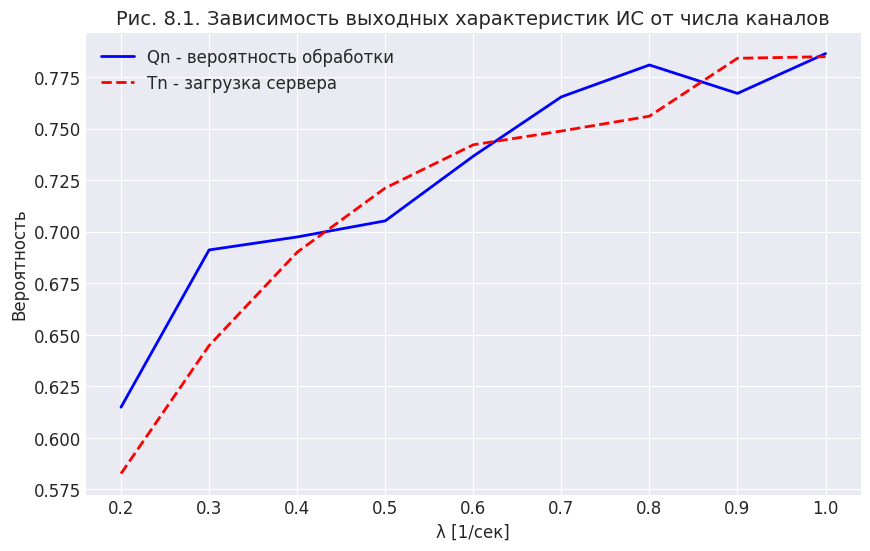


Результаты задания №3:
n   λ    Qn     Tn
------------------------------
2   0.2   0.6149   0.5827
3   0.3   0.6912   0.6448
4   0.4   0.6975   0.6901
5   0.5   0.7053   0.7212
6   0.6   0.7367   0.7422
7   0.7   0.7654   0.7489
8   0.8   0.7809   0.7561
9   0.9   0.7671   0.7842
10   1.0   0.7864   0.7849


In [22]:
# Задание №3
# Исследование зависимости от числа каналов с пропорциональным увеличением интенсивности входного потока

print("=" * 60)
print("Задание №3: Исследование зависимости от числа каналов")
print("=" * 60)

# Параметры моделирования
mu = 0.1  # интенсивность обработки для одного канала [1/сек]
T_simulation = 1000  # время моделирования [сек]
num_runs = 10  # количество прогонов для каждого набора параметров

# Число каналов и соответствующие интенсивности входного потока (пропорционально n)
ns = np.arange(2, 11)  # n = 2, 3, 4, 5, 6, 7, 8, 9, 10
lmbds = ns * 0.1  # λ = 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0

print(f"\nПараметры исследования:")
print(f"μ = {mu} [1/сек]")
print(f"T = {T_simulation} [сек]")

# Функция для генерации времен поступления заявок
def generate_request_time_exp(lambda_rate, T_simulation):
    request_times = []
    current_time = 0
    while current_time < T_simulation:
        current_time += generate_exponential(lambda_rate)
        if current_time < T_simulation:
            request_times.append(current_time)
    return np.array(request_times)

# Функция для генерации времен обработки
def generate_process_time_exp(mu_rate, num_requests):
    process_times = []
    for _ in range(num_requests):
        process_times.append(generate_exponential(mu_rate))
    return np.array(process_times)

# Функция симуляции многоканальной системы
def simulate(request_times, process_times, n_channels):
    channel_free_times = np.zeros(n_channels)
    work_times = np.zeros(n_channels)
    processed_signals = 0
    
    for i, req_time in enumerate(request_times):
        free_channel = -1
        for j in range(n_channels):
            if channel_free_times[j] <= req_time:
                free_channel = j
                break
        
        if free_channel != -1:
            processed_signals += 1
            finish_time = req_time + process_times[i]
            channel_free_times[free_channel] = finish_time
            work_times[free_channel] += process_times[i]
    
    return processed_signals, work_times

# Проведение исследования
all_qn = []  # вероятности обработки (Qn)
all_tn = []  # загрузка сервера (Tn)

print("\nВыполнение моделирования...")
for i in range(len(ns)):
    n = ns[i]
    lmbd = lmbds[i]
    
    cur_qn = []
    cur_tn = []
    
    for run in range(num_runs):
        np.random.seed(run * 100 + n)
        
        T_req = generate_request_time_exp(lmbd, T_simulation)
        T_processing = generate_process_time_exp(mu, len(T_req))
        
        processed_signals, work_times = simulate(T_req, T_processing, n)
        
        if len(T_req) > 0:
            p_processed = processed_signals / len(T_req)
        else:
            p_processed = 0
        cur_qn.append(p_processed)
        
        avg_utilization = np.sum(work_times) / (n * T_simulation)
        cur_tn.append(avg_utilization)
    
    avg_qn = np.mean(cur_qn)
    avg_tn = np.mean(cur_tn)
    
    all_qn.append(avg_qn)
    all_tn.append(avg_tn)
    
    print(f"n={n}, λ={lmbd:.1f}: Qn={avg_qn:.4f}, Tn={avg_tn:.4f}")

# Простой график как на рисунке 8.1
plt.figure(figsize=(10, 6))
plt.plot(lmbds, all_qn, 'b-', linewidth=2,  label='Qn - вероятность обработки')
plt.plot(lmbds, all_tn, 'r--', linewidth=2,  label='Tn - загрузка сервера')
plt.xlabel('λ [1/сек]', fontsize=12)
plt.ylabel('Вероятность', fontsize=12)
plt.title('Рис. 8.1. Зависимость выходных характеристик ИС от числа каналов', fontsize=14)
plt.legend()
plt.show()

# Таблица результатов
print("\n" + "=" * 60)
print("Результаты задания №3:")
print("=" * 60)
print("n   λ    Qn     Tn")
print("-" * 30)
for i in range(len(ns)):
    print(f"{ns[i]:d}   {lmbds[i]:.1f}   {all_qn[i]:.4f}   {all_tn[i]:.4f}")

### Exercise 4

Задание №4: Исследование при увеличении интенсивности обработки

Параметры исследования:
n = 1 (одноканальная система)
T = 1000 [сек]
Исследуемые конфигурации:
  μ=0.1 [1/сек], λ=0.1 [1/сек]
  μ=0.2 [1/сек], λ=0.2 [1/сек]
  μ=0.3 [1/сек], λ=0.3 [1/сек]
  μ=0.4 [1/сек], λ=0.4 [1/сек]
  μ=0.5 [1/сек], λ=0.5 [1/сек]
  μ=0.6 [1/сек], λ=0.6 [1/сек]
  μ=0.7 [1/сек], λ=0.7 [1/сек]
  μ=0.8 [1/сек], λ=0.8 [1/сек]
  μ=0.9 [1/сек], λ=0.9 [1/сек]
  μ=1.0 [1/сек], λ=1.0 [1/сек]

Выполнение моделирования...
------------------------------------------------------------
Моделирование: μ=0.1, λ=0.1
  Q1=0.5464, T1=0.5096
Моделирование: μ=0.2, λ=0.2
  Q1=0.5158, T1=0.5069
Моделирование: μ=0.3, λ=0.3
  Q1=0.4060, T1=0.5690
Моделирование: μ=0.4, λ=0.4
  Q1=0.5090, T1=0.4792
Моделирование: μ=0.5, λ=0.5
  Q1=0.5435, T1=0.4680
Моделирование: μ=0.6, λ=0.6
  Q1=0.4824, T1=0.5066
Моделирование: μ=0.7, λ=0.7
  Q1=0.5118, T1=0.5098
Моделирование: μ=0.8, λ=0.8
  Q1=0.4816, T1=0.4955
Моделирование: μ=0.9, λ=0.9
  Q1

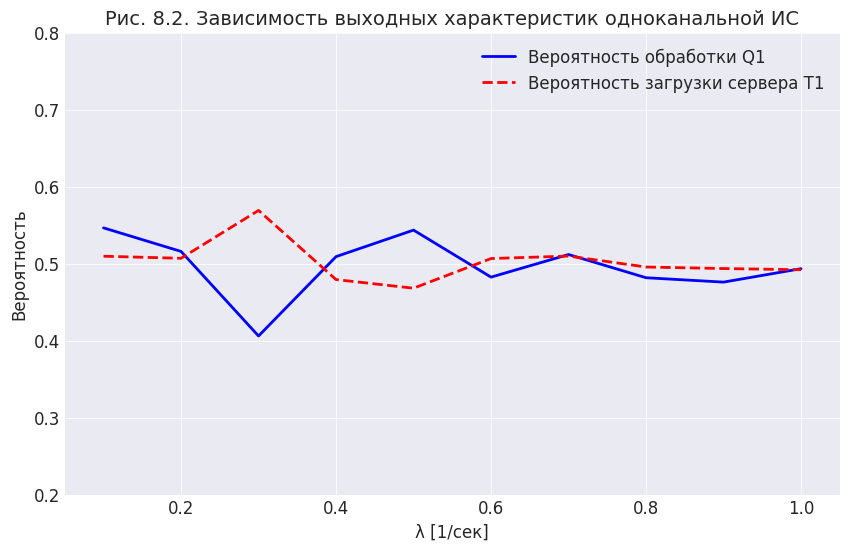


Результаты задания №4:
                  Q1 (вероятность обработки)  T1 (загрузка сервера)
μ = 0.1, λ = 0.1                      0.5464                 0.5096
μ = 0.2, λ = 0.2                      0.5158                 0.5069
μ = 0.3, λ = 0.3                      0.4060                 0.5690
μ = 0.4, λ = 0.4                      0.5090                 0.4792
μ = 0.5, λ = 0.5                      0.5435                 0.4680
μ = 0.6, λ = 0.6                      0.4824                 0.5066
μ = 0.7, λ = 0.7                      0.5118                 0.5098
μ = 0.8, λ = 0.8                      0.4816                 0.4955
μ = 0.9, λ = 0.9                      0.4759                 0.4936
μ = 1.0, λ = 1.0                      0.4934                 0.4920

ВЫВОДЫ ПО ЗАДАНИЮ №4:

При увеличении интенсивности входного потока и пропорциональном
увеличении интенсивности обработки в одноканальной системе:

- Вероятность обработки Q1 стремится к 0.4934
- Загрузка сервера T1 стремится к

In [32]:
# Задание №4
# Исследование при увеличении интенсивности обработки

print("=" * 60)
print("Задание №4: Исследование при увеличении интенсивности обработки")
print("=" * 60)

# Параметры моделирования
n = 1  # одноканальная система
T = 1000  # время моделирования [сек]

# Интенсивности обработки и входного потока (пропорционально)
mus = np.arange(1, 11) * 0.1  # μ = 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0
lmbds = np.arange(1, 11) * 0.1  # λ = 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0

print(f"\nПараметры исследования:")
print(f"n = {n} (одноканальная система)")
print(f"T = {T} [сек]")
print(f"Исследуемые конфигурации:")
for mu, lmbd in zip(mus, lmbds):
    print(f"  μ={mu:.1f} [1/сек], λ={lmbd:.1f} [1/сек]")

# Функция для генерации времен поступления заявок
def generate_request_time_exp(lambda_rate, T_simulation):
    request_times = []
    current_time = 0
    while current_time < T_simulation:
        current_time += generate_exponential(lambda_rate)
        if current_time < T_simulation:
            request_times.append(current_time)
    return np.array(request_times)

# Функция для генерации времен обработки
def generate_process_time_exp(mu_rate, num_requests):
    process_times = []
    for _ in range(num_requests):
        process_times.append(generate_exponential(mu_rate))
    return np.array(process_times)

# Функция симуляции одноканальной системы
def simulate(request_times, process_times, n_channels):
    if n_channels != 1:
        raise ValueError("Эта функция только для одноканальной системы")
    
    channel_busy_until = 0
    work_time = 0
    processed_signals = 0
    
    for i, req_time in enumerate(request_times):
        if req_time >= channel_busy_until:
            # Канал свободен
            processed_signals += 1
            service_time = process_times[i]
            work_time += service_time
            channel_busy_until = req_time + service_time
        # else: канал занят - отказ
    
    work_times = [work_time]
    free_time = 0
    rej_time = 0
    
    return processed_signals, work_times, free_time, rej_time

# Проведение исследования
all_ps = []  # вероятности обработки (Q1)
all_wts = []  # загрузка сервера (T1)

print("\nВыполнение моделирования...")
print("-" * 60)

for i in range(len(mus)):
    mu = mus[i]
    lmbd = lmbds[i]
    
    print(f"Моделирование: μ={mu:.1f}, λ={lmbd:.1f}")
    
    c = 1  # один прогон для каждой точки (как в вашем примере)
    cur_p = []
    cur_wt = []
    
    for _ in range(c):
        np.random.seed(i * 10 + _)  # для воспроизводимости
        
        # Генерация времен поступления заявок
        T_req = generate_request_time_exp(lmbd, T)
        
        # Генерация времен обработки для каждой заявки
        T_processing = generate_process_time_exp(mu, len(T_req))
        
        # Симуляция
        processed_signals, work_times, free_time, rej_time = simulate(T_req, T_processing, n)
        
        if len(T_req) > 0:
            cur_p.append(processed_signals / len(T_req))
        else:
            cur_p.append(0)
        
        cur_wt.append(work_times[0] / T)
    
    all_ps.append(np.mean(cur_p))
    all_wts.append(np.mean(cur_wt))
    
    print(f"  Q1={all_ps[-1]:.4f}, T1={all_wts[-1]:.4f}")

print("-" * 60)


# Простой график 
plt.figure(figsize=(10, 6))
plt.plot(lmbds, all_ps, 'b-', linewidth=2, label="Вероятность обработки Q1")
plt.plot(lmbds, all_wts, 'r--', linewidth=2, label="Вероятность загрузки сервера T1")
plt.xlabel("λ [1/сек]", fontsize=12)
plt.ylabel("Вероятность", fontsize=12)
plt.title("Рис. 8.2. Зависимость выходных характеристик одноканальной ИС", fontsize=14)
plt.legend()
plt.xlim(0.05, 1.05)
plt.ylim(0.2, 0.8)
plt.grid(True, alpha=0.8)
plt.show()

# Таблица результатов
print("\n" + "=" * 60)
print("Результаты задания №4:")
print("=" * 60)

table_rows = [f"μ = {mu:.1f}, λ = {lmbd:.1f}" for mu, lmbd in zip(mus, lmbds)]
df = pd.DataFrame({
    "Q1 (вероятность обработки)": all_ps,
    "T1 (загрузка сервера)": all_wts
}, index=table_rows)

df = df.round(4)
print(df.to_string())

print("\n" + "=" * 60)
print("ВЫВОДЫ ПО ЗАДАНИЮ №4:")
print("=" * 60)
print(f"""
При увеличении интенсивности входного потока и пропорциональном
увеличении интенсивности обработки в одноканальной системе:

- Вероятность обработки Q1 стремится к {all_ps[-1]:.4f}
- Загрузка сервера T1 стремится к {all_wts[-1]:.4f}
- Теоретически обе величины должны стремиться к 0.5
""")